<a href="https://colab.research.google.com/github/ChandraMouli2727/Rough/blob/main/DL/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
#get_ipython.run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving insurance_data_1.csv to insurance_data_1.csv


{'insurance_data_1.csv': b'age,affordibility,bought_insurance\n22,1,0\n25,0,0\n47,1,1\n52,0,0\n46,1,1\n56,1,1\n55,0,0\n60,0,1\n62,1,1\n61,1,1\n18,1,0\n28,1,0\n27,0,0\n29,0,0\n49,1,1\n55,1,1\n25,0,1\n58,1,1\n19,0,0\n18,1,0\n21,1,0\n26,0,0\n40,1,1\n45,1,1\n50,1,1\n54,1,1\n23,1,0\n46,1,0\n'}

In [ ]:
import pandas as pd
df = pd.read_csv("insurance_data_1.csv")
print(df.head())


   age  affordibility  bought_insurance
0   22              1                 0
1   25              0                 0
2   47              1                 1
3   52              0                 0
4   46              1                 1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df[['age','affordibility']],df.bought_insurance,test_size=0.2,random_state=25)

In [ ]:
len(X_train)

22

In [ ]:
X_train_scaled = X_train.copy()
X_train_scaled['age'] = X_train_scaled['age']/100
X_test_scaled = X_test.copy()
X_test_scaled['age'] = X_test_scaled['age']/100

In [ ]:
X_train_scaled.head()

,age,affordibility
0,0.22,1
13,0.29,0
6,0.55,0
17,0.58,1
24,0.50,1


In [ ]:
model = keras.Sequential([
    keras.layers.Dense(1,input_shape=(2,),activation='sigmoid',kernel_initializer='ones',bias_initializer='zeros')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train_scaled,y_train,epochs=5) # go upto 5000 until accuracy is 90

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step - accuracy: 0.5000 - loss: 0.7113
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7110
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7106
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.7102
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.7098


In [ ]:
model.evaluate(X_test_scaled,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5000 - loss: 0.7305


[0.730549156665802, 0.5]

In [ ]:
X_test_scaled

,age,affordibility
2,0.47,1
10,0.18,1
21,0.26,0
11,0.28,1
14,0.49,1
9,0.61,1


In [ ]:
model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[0.8111734 ],
       [0.7629826 ],
       [0.5630873 ],
       [0.78050345],
       [0.8142026 ],
       [0.8315921 ]], dtype=float32)

In [ ]:
y_test

,bought_insurance
2,1
10,0
21,0
11,0
14,1
9,1


In [ ]:
coef,intercept = model.get_weights()
print(coef) #w1,w2
print(intercept)#bias

[[0.99500155]
 [0.9950011 ]]
[-0.00499922]


In [ ]:
def sigmoid(x):
  import math
  return 1/(1+math.exp(-x))
sigmoid(18)


0.9999999847700205

In [ ]:
def prediction_function(age,affordibility):
  weighted_sum = coef[0]*age + coef[1]*affordibility + intercept
  return sigmoid(weighted_sum)

In [ ]:
prediction_function(0.47,1)

In [ ]:
def sigmoid_numpy(X):
   return 1/(1+np.exp(-X))

sigmoid_numpy(np.array([12,0,1]))

array([0.99999386, 0.5       , 0.73105858])

In [ ]:
def log_loss(y_true, y_predicted):
    epsilon = 1e-15
    y_predicted_new = [max(i,epsilon) for i in y_predicted]
    y_predicted_new = [min(i,1-epsilon) for i in y_predicted_new]
    y_predicted_new = np.array(y_predicted_new)
    return -np.mean(y_true*np.log(y_predicted_new)+(1-y_true)*np.log(1-y_predicted_new))

In [ ]:
def gradient_descent(age, affordability, y_true, epochs, loss_thresold):
    w1 = w2 = 1
    bias = 0
    rate = 0.5
    n = len(age)
    for i in range(epochs):
        weighted_sum = w1 * age + w2 * affordability + bias
        y_predicted = sigmoid_numpy(weighted_sum)
        loss = log_loss(y_true, y_predicted)

        w1d = (1/n)*np.dot(np.transpose(age),(y_predicted-y_true))
        w2d = (1/n)*np.dot(np.transpose(affordability),(y_predicted-y_true))

        bias_d = np.mean(y_predicted-y_true)
        w1 = w1 - rate * w1d
        w2 = w2 - rate * w2d
        bias = bias - rate * bias_d

        print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

        if loss<=loss_thresold:
            break

    return w1, w2, bias

In [ ]:
#gradient_descent(X_train_scaled['age'],X_train_scaled['affordibility'],y_train,1000, 0.4631)

In [ ]:
class myNN:
    def __init__(self):
        self.w1 = 1
        self.w2 = 1
        self.bias = 0

    def fit(self, X, y, epochs, loss_thresold):
        self.w1, self.w2, self.bias = self.gradient_descent(X['age'],X['affordibility'],y, epochs, loss_thresold)
        print(f"Final weights and bias: w1: {self.w1}, w2: {self.w2}, bias: {self.bias}")

    def predict(self, X_test):
        weighted_sum = self.w1*X_test['age'] + self.w2*X_test['affordibility'] + self.bias
        return sigmoid_numpy(weighted_sum)

    def gradient_descent(self, age,affordability, y_true, epochs, loss_thresold):
        w1 = w2 = 1
        bias = 0
        rate = 0.5
        n = len(age)
        for i in range(epochs):
            weighted_sum = w1 * age + w2 * affordability + bias
            y_predicted = sigmoid_numpy(weighted_sum)
            loss = log_loss(y_true, y_predicted)

            w1d = (1/n)*np.dot(np.transpose(age),(y_predicted-y_true))
            w2d = (1/n)*np.dot(np.transpose(affordability),(y_predicted-y_true))

            bias_d = np.mean(y_predicted-y_true)
            w1 = w1 - rate * w1d
            w2 = w2 - rate * w2d
            bias = bias - rate * bias_d

            if i%50==0:
                print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

            if loss<=loss_thresold:
                print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')
                break

        return w1, w2, bias

In [ ]:

customModel = myNN()
customModel.fit(X_train_scaled, y_train, epochs=8, loss_thresold=0.4631)

Epoch:0, w1:0.974907633470177, w2:0.948348125394529, bias:-0.11341867736368583, loss:0.7113403233723417
Final weights and bias: w1: 0.93047170420295, w2: 0.7983920007454487, bias: -0.5790424270894963


In [ ]:
coef, intercept

(array([[0.99500155],
        [0.9950011 ]], dtype=float32),
 array([-0.00499922], dtype=float32))

In [ ]:

X_test_scaled

,age,affordibility
2,0.47,1
10,0.18,1
21,0.26,0
11,0.28,1
14,0.49,1
9,0.61,1


In [ ]:
customModel.predict(X_test_scaled)

,0
2,0.658512
10,0.595520
21,0.416509
11,0.617720
14,0.662685
9,0.687173


In [ ]:

model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.8111734 ],
       [0.7629826 ],
       [0.5630873 ],
       [0.78050345],
       [0.8142026 ],
       [0.8315921 ]], dtype=float32)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving homeprices_banglore.csv to homeprices_banglore.csv


In [ ]:
df = pd.read_csv('homeprices_banglore.csv')
df.sample(5)

,area,bedrooms,price
3,1521,3,75.0
11,2785,4,140.0
13,1100,2,40.0
18,2770,3,102.0
19,800,1,32.0


In [ ]:
#sccale values for better results
from sklearn import preprocessing
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_x = sx.fit_transform(df.drop('price',axis='columns'))
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [ ]:
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1))

In [ ]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [ ]:
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [ ]:
scaled_x.T

array([[0.08827586, 0.62068966, 0.22068966, 0.24862069, 0.13793103,
        0.12758621, 0.6662069 , 0.86206897, 0.17586207, 1.        ,
        0.34482759, 0.68448276, 0.06896552, 0.10344828, 0.5       ,
        0.12931034, 0.13103448, 0.25517241, 0.67931034, 0.        ],
       [0.25      , 0.75      , 0.5       , 0.5       , 0.25      ,
        0.25      , 0.75      , 0.75      , 0.5       , 1.        ,
        0.5       , 0.75      , 0.25      , 0.25      , 0.5       ,
        0.25      , 0.5       , 0.5       , 0.5       , 0.        ]])

In [ ]:
w = np.ones(shape=(2))
w

array([1., 1.])

In [ ]:
np.dot(w,scaled_x.T)

array([0.33827586, 1.37068966, 0.72068966, 0.74862069, 0.38793103,
       0.37758621, 1.4162069 , 1.61206897, 0.67586207, 2.        ,
       0.84482759, 1.43448276, 0.31896552, 0.35344828, 1.        ,
       0.37931034, 0.63103448, 0.75517241, 1.17931034, 0.        ])

In [ ]:
def batch_gradient_descent(X, y_true, epochs, learning_rate=0.01):
  number_of_features = X.shape[1]
  # Step 1
  w = np.ones(shape=(number_of_features))
  b = 0
  total_samples = X.shape[0]

  cost_list = []
  epoch_list = []
  # Step 2
  for i in range(epochs):
    y_predicted = np.dot(w, X.T) + b

    #w_grad = (1/total_samples)*np.dot(X.T, (y_predicted-y_true))
    #b_grad = (1/total_samples)*np.dot((y_predicted-y_true), np.ones(shape=(total_samples)))

    w_grad = -(2/total_samples)*(X.T.dot(y_true-y_predicted))
    b_grad = -(2/total_samples)*np.sum((y_true-y_predicted))

    w = w - learning_rate * w_grad
    b = b - learning_rate * b_grad

    cost = np.mean(np.square(y_true-y_predicted))
    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)
      #print (f'Epoch: {i}, w:{w}, b:{b}, loss: {cost}')

  return w, b,cost,cost_list,epoch_list

In [ ]:

  w,b,cost,cost_list,epoch_list = batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0]),100)
  w,b,cost # go with 500 epochs to get curve somewhat better than this

(array([0.82015506, 0.78816915]),
 np.float64(-0.3027445983749067),
 np.float64(0.015813309382911644))

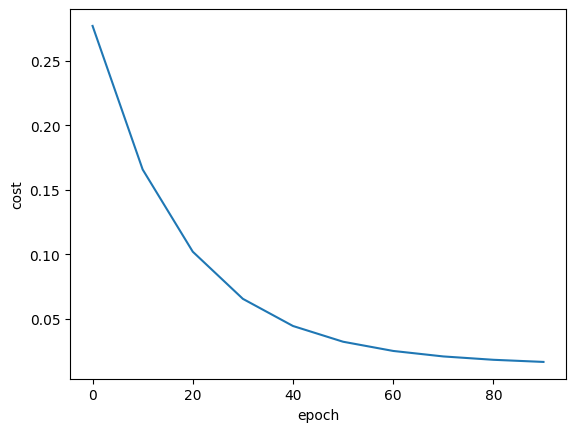

In [ ]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)
#

In [ ]:
w

array([0.82015506, 0.78816915])

In [ ]:
sy.inverse_transform([[1,0]])

array([[167.,  32.]])

In [ ]:
def predict(area,bedrooms,w,b):
  scaled_x =[area,bedrooms]
  scaled_x = sx.transform([scaled_x])
  print(scaled_x)
  y = w[0]*scaled_x[0][0] + w[1]*scaled_x[0][1] + b
  return sy.inverse_transform([[y]])[0][0]

In [ ]:
predict(2600,4,w,b)

[[0.62068966 0.75      ]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(139.65494313354682)

In [ ]:
predict(1000,2,w,b)

[[0.06896552 0.25      ]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(25.366114421545145)

In [ ]:
import random
random.randint(0,6)

0

In [ ]:
def stotchastic_gradient_descent(X, y_true, epochs, learning_rate=0.01):
  number_of_features = X.shape[1]
  # Step 1
  w = np.ones(shape=(number_of_features))
  b = 0
  total_samples = X.shape[0]

  cost_list = []
  epoch_list = []
  # Step 2
  for i in range(epochs):
    random_index = random.randint(0,total_samples-1)
    sample_x = X[random_index]
    sample_y = y_true[random_index]
    y_predicted = np.dot(w, sample_x.T) + b

    w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad = -(2/total_samples)*(sample_y-y_predicted)

    w = w - learning_rate * w_grad
    b = b - learning_rate * b_grad
    cost = np.square(sample_y-y_predicted)
    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)
      #print (f'Epoch: {i}, w:{w}, b:{b}, loss: {cost}')
    return w, b,cost,cost_list,epoch_list

In [ ]:
w_sgd,b_sgd,cost_sgd,cost_list_sgd,epoch_list_sgd = stotchastic_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0]),100)
w_sgd,b_sgd,cost_sgd

(array([0.9995648 , 0.99951007]),
 np.float64(-0.0006532439335887612),
 np.float64(0.4267276367705177))

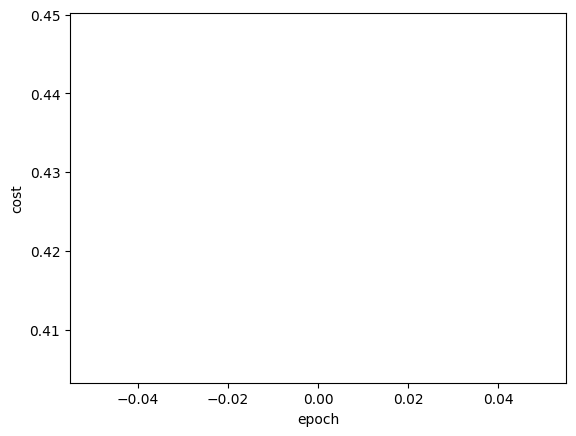

In [ ]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

In [ ]:
predict(2600,4,w_sgd,b_sgd)

[[0.62068966 0.75      ]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(216.86884341495653)

In [ ]:
def mini_batch_gradient_descent(X, y_true, epochs = 100, batch_size = 5, learning_rate = 0.01):

    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In
    # our case number_of_features = 3 (area, bedroom and age)
    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = X.shape[0] # number of rows in X

    if batch_size > total_samples: # In this case mini batch becomes same as batch gradient descent
        batch_size = total_samples

    cost_list = []
    epoch_list = []

    num_batches = int(total_samples/batch_size)

    for i in range(epochs):
        random_indices = np.random.permutation(total_samples)
        X_tmp = X[random_indices]
        y_tmp = y_true[random_indices]

        for j in range(0,total_samples,batch_size):
            Xj = X_tmp[j:j+batch_size]
            yj = y_tmp[j:j+batch_size]
            y_predicted = np.dot(w, Xj.T) + b

            w_grad = -(2/len(Xj))*(Xj.T.dot(yj-y_predicted))
            b_grad = -(2/len(Xj))*np.sum(yj-y_predicted)

            w = w - learning_rate * w_grad
            b = b - learning_rate * b_grad

            cost = np.mean(np.square(yj-y_predicted)) # MSE (Mean Squared Error)

        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)

    return w, b, cost, cost_list, epoch_list

In [ ]:


w, b, cost, cost_list, epoch_list = mini_batch_gradient_descent(
    scaled_x,
    scaled_y.reshape(scaled_y.shape[0],),
    epochs = 120,
    batch_size = 5
)
w, b, cost

(array([0.70991518, 0.67790982]),
 np.float64(-0.23357312840095504),
 np.float64(0.003197192537566479))